In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns

df = pd.read_csv('melb_data.csv')
df.shape

(13580, 21)

What are the key factors that influence house prices in Melbourne, and how can we build a model to predict the price of a property based on its features?

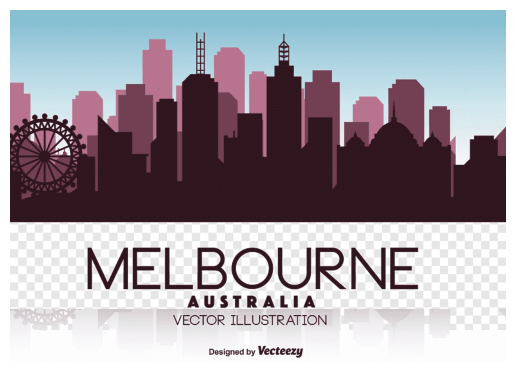

In [14]:
img = mpimg.imread('png-clipart-melbourne-skyline-city-building-illustration.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Melbourne, one of Australia's largest and fastest-growing cities, has experienced significant fluctuations in its real estate market over the past decade. For homebuyers, sellers, real estate agents, and investors, understanding which property features most strongly affect prices is crucial for making informed decisions.

With soaring housing costs and increasing demand for urban living, data-driven insights can:

- Help buyers find affordable options with the best value;
- Guide sellers in pricing their properties competitively;
- Support real estate professionals with objective market analysis;
- Enable financial institutions to assess property-related risks more accurately.

Using this dataset, we aim to identify the most influential variables and develop a predictive model

Data Cleaning.

1. Handling missing values

In [15]:
print(df.isnull().sum().sort_values(ascending=False))

BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Car                62
Suburb              0
Bathroom            0
Regionname          0
Longtitude          0
Lattitude           0
Landsize            0
Bedroom2            0
Address             0
Postcode            0
Distance            0
Date                0
SellerG             0
Method              0
Price               0
Type                0
Rooms               0
Propertycount       0
dtype: int64


In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

2. Removing duplicates

In [25]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


3. Handling inconsistent formats

In [33]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

4. Handling outliers

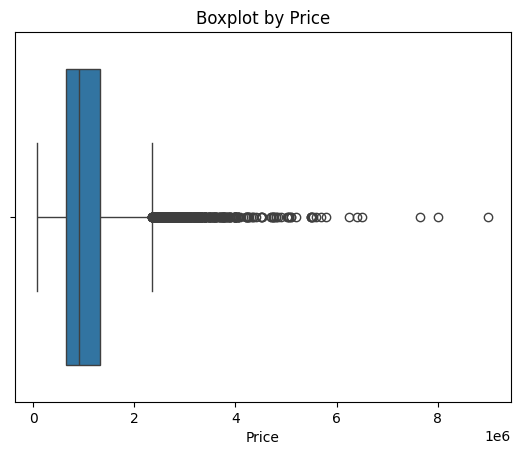

In [28]:
sns.boxplot(x=df['Price'])
plt.title('Boxplot by Price')
plt.show()

In [29]:
q99_price = df['Price'].quantile(0.99)
df = df[df['Price'] < q99_price]

5. Feature Engineering

In [34]:
df['HouseAge'] = 2025 - df['YearBuilt']
df['RoomDensity'] = df['Rooms'] / (df['Landsize'] + 1)
df['SaleYear'] = df['Date'].dt.year
df['SaleMonth'] = df['Date'].dt.month

In [36]:
df.to_csv('Melbourne_cleaned.csv', index=False)
print("✅ Data cleaning completed. Dataset is ready for EDA and modeling.")

✅ Data cleaning completed. Dataset is ready for EDA and modeling.


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13444 entries, 0 to 13579
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13444 non-null  object        
 1   Address        13444 non-null  object        
 2   Rooms          13444 non-null  int64         
 3   Type           13444 non-null  object        
 4   Price          13444 non-null  float64       
 5   Method         13444 non-null  object        
 6   SellerG        13444 non-null  object        
 7   Date           5084 non-null   datetime64[ns]
 8   Distance       13444 non-null  float64       
 9   Postcode       13444 non-null  float64       
 10  Bedroom2       13444 non-null  float64       
 11  Bathroom       13444 non-null  float64       
 12  Car            13444 non-null  float64       
 13  Landsize       13444 non-null  float64       
 14  BuildingArea   13444 non-null  float64       
 15  YearBuilt      13444 non

<class 'pandas.core.frame.DataFrame'>
Index: 13444 entries, 0 to 13579
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13444 non-null  object        
 1   Address        13444 non-null  object        
 2   Rooms          13444 non-null  int64         
 3   Type           13444 non-null  object        
 4   Price          13444 non-null  float64       
 5   Method         13444 non-null  object        
 6   SellerG        13444 non-null  object        
 7   Date           5084 non-null   datetime64[ns]
 8   Distance       13444 non-null  float64       
 9   Postcode       13444 non-null  float64       
 10  Bedroom2       13444 non-null  float64       
 11  Bathroom       13444 non-null  float64       
 12  Car            13444 non-null  float64       
 13  Landsize       13444 non-null  float64       
 14  BuildingArea   13444 non-null  float64       
 15  YearBuilt      13444 non

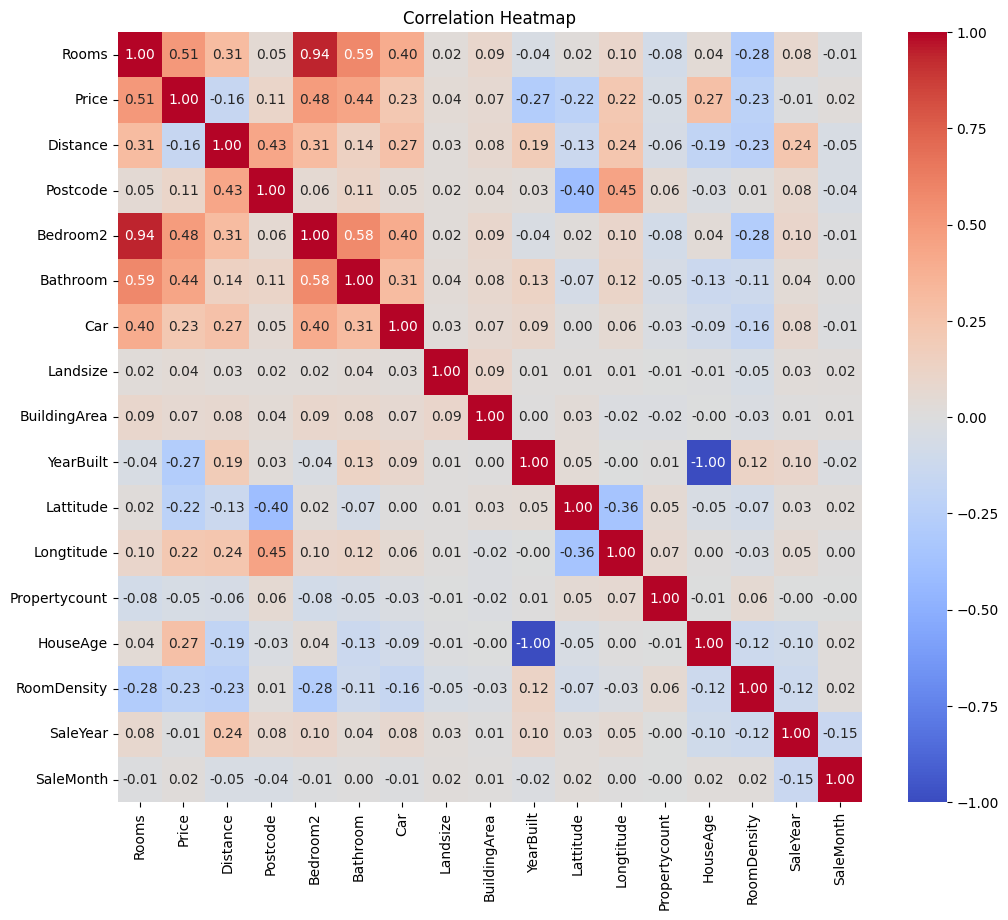

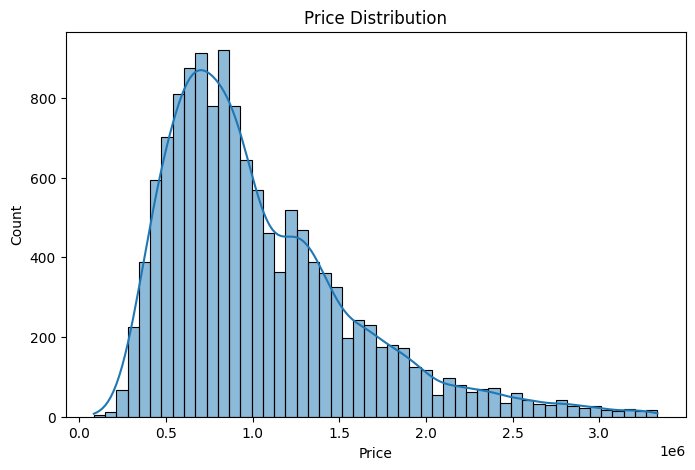

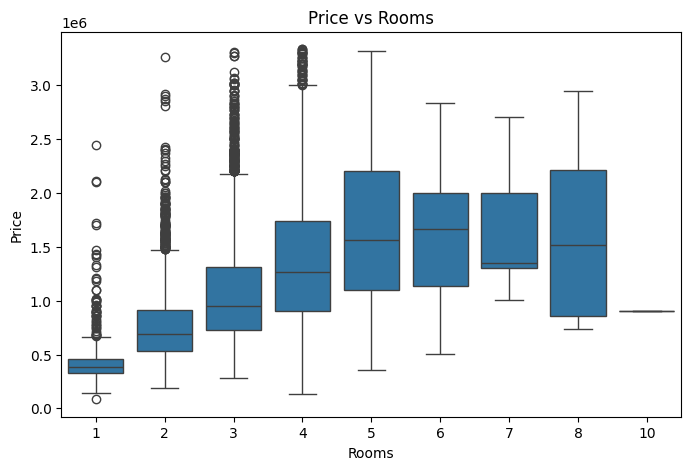

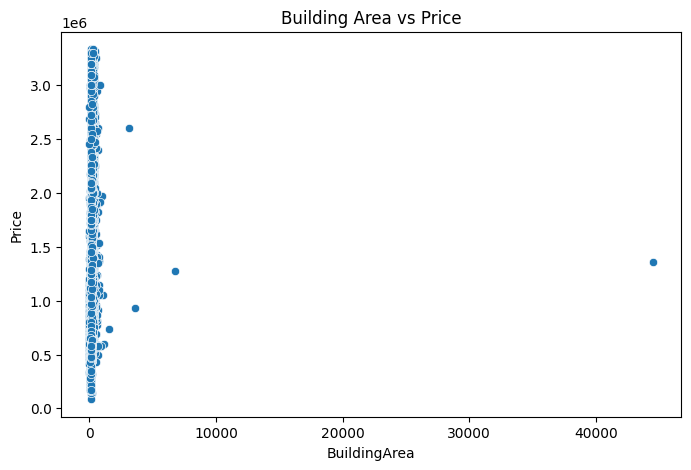

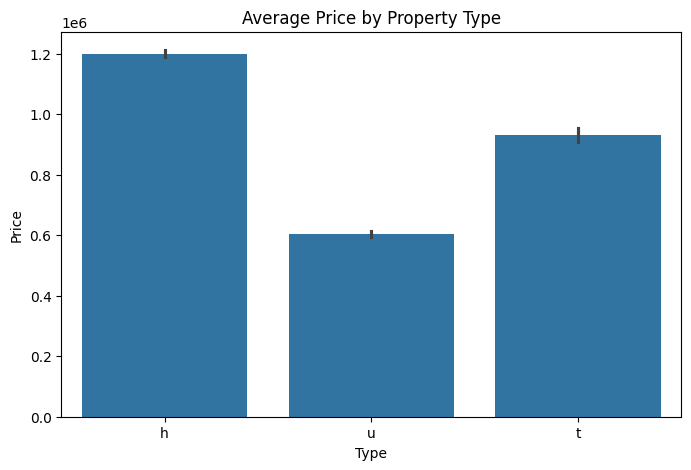

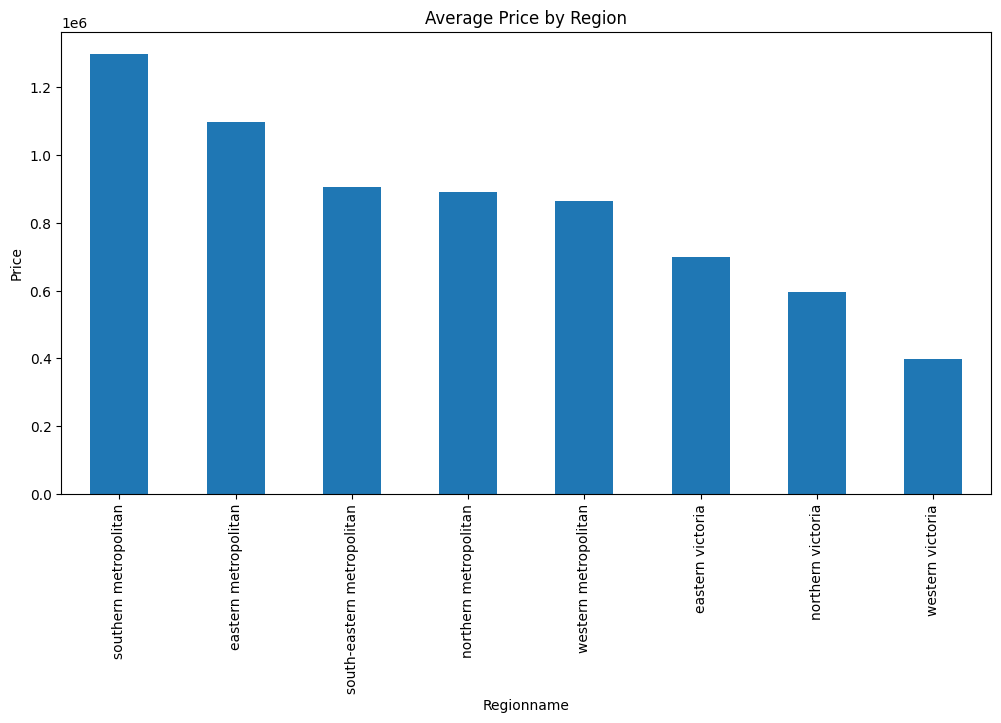

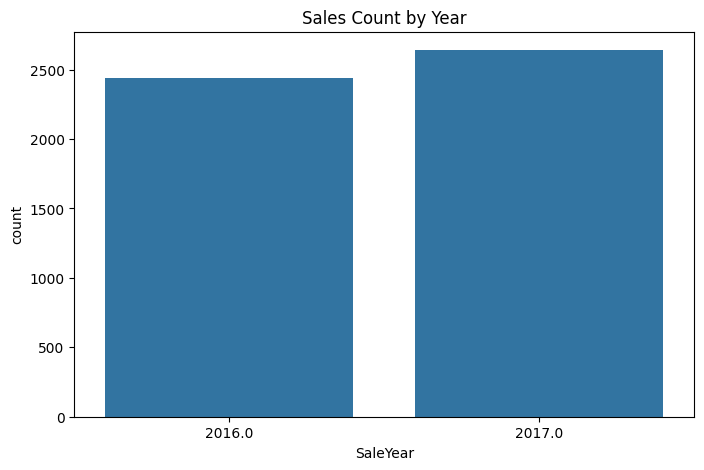

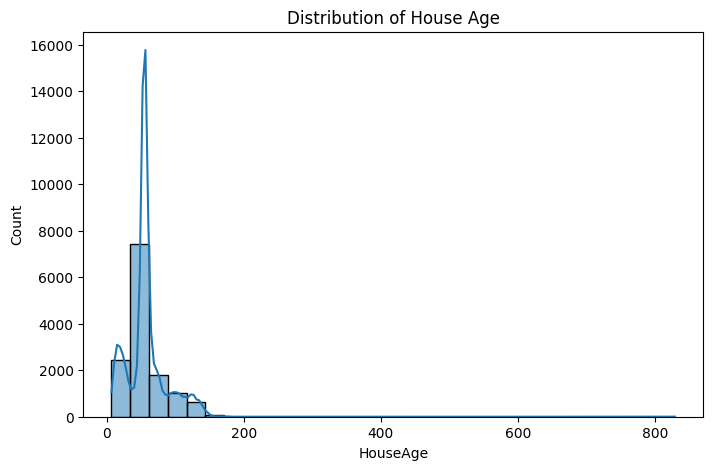

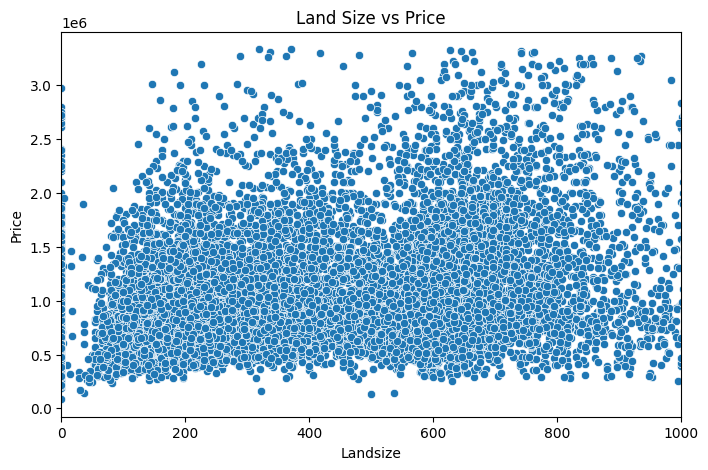

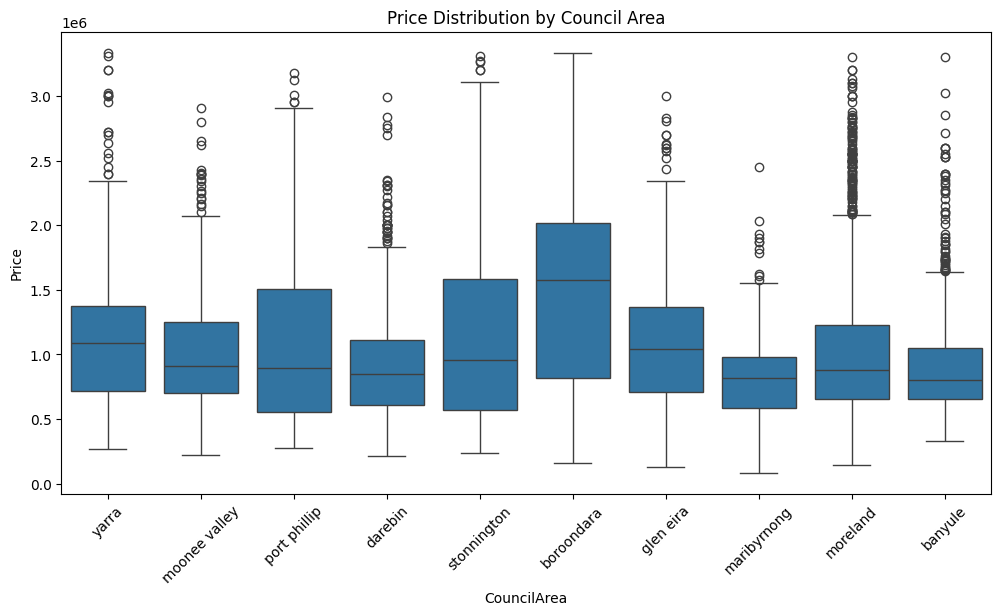

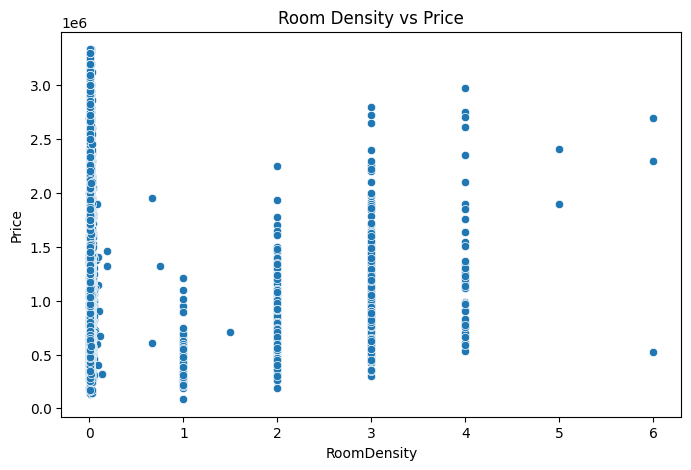

In [38]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Rooms', y='Price', data=df)
plt.title('Price vs Rooms')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='BuildingArea', y='Price', data=df)
plt.title('Building Area vs Price')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='Type', y='Price', data=df)
plt.title('Average Price by Property Type')
plt.show()

plt.figure(figsize=(12, 6))
top_regions = df.groupby('Regionname')['Price'].mean().sort_values(ascending=False)
top_regions.plot(kind='bar')
plt.title('Average Price by Region')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='SaleYear', data=df)
plt.title('Sales Count by Year')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['HouseAge'], bins=30, kde=True)
plt.title('Distribution of House Age')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Landsize', y='Price', data=df)
plt.title('Land Size vs Price')
plt.xlim(0, 1000)
plt.show()

top_councils = df['CouncilArea'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='CouncilArea', y='Price', data=df[df['CouncilArea'].isin(top_councils)])
plt.title('Price Distribution by Council Area')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='RoomDensity', y='Price', data=df)
plt.title('Room Density vs Price')
plt.show()